In [9]:
import numpy as np
import matplotlib.pyplot as plt
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

In [10]:
# GW150914 — first gravitational wave ever detected
# September 14, 2015, 09:50:45 UTC
gps = event_gps('GW150914')
print(f"GPS time of GW150914: {gps}")


GPS time of GW150914: 1126259462.4


In [11]:
strain = TimeSeries.read('GW150914_H1.hdf5', format='hdf5.gwosc')
print(strain)

TimeSeries([9.06730891e-21, 2.01178871e-20, 3.71290472e-20, ...,
            5.32101440e-20, 4.74831535e-20, 7.76456828e-20],
           unit: dimensionless,
           t0: 1126259447.0 s,
           dt: 0.000244140625 s,
           name: H1:Strain,
           channel: None)


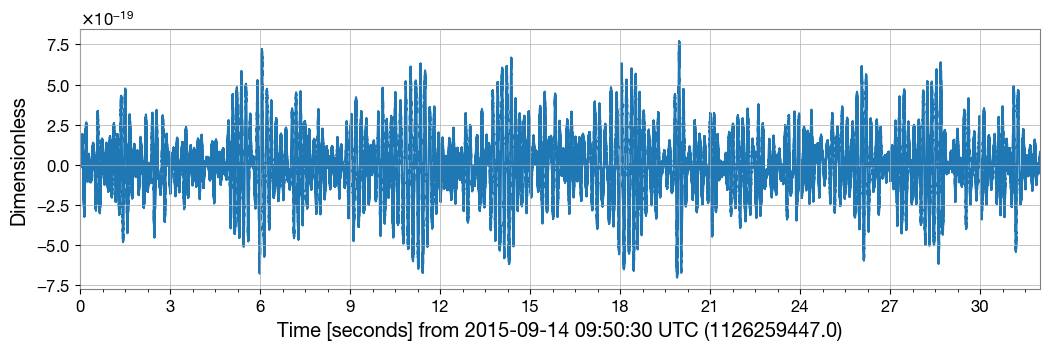

In [12]:
strain.plot()
plt.show()


Raw strain data bandpass filter, keep ony 50 - 300 HZ. Freq band where grav chirps live. 

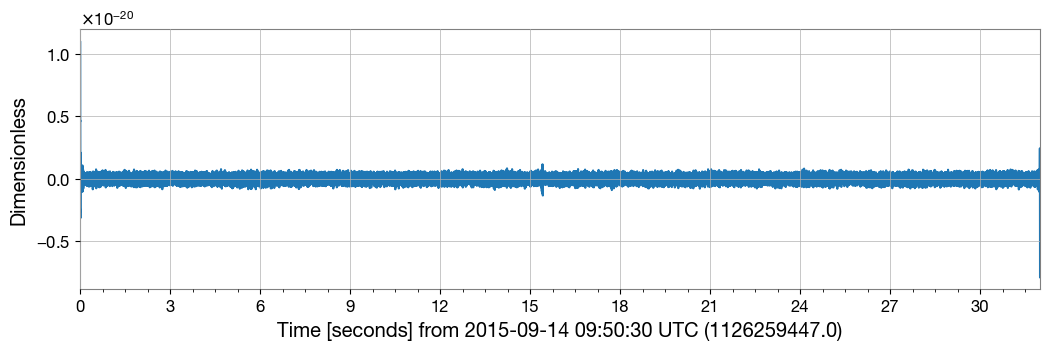

In [13]:

strain_filtered = strain.bandpass(50, 300)
strain_filtered.plot()
plt.show()

In [14]:
print(f"GPS event time: {gps}")
print(f"Strain start time: {strain.t0.value}")
print(f"Strain end time: {strain.t0.value + len(strain)*strain.dt.value}")
print(f"Event offset: {gps - strain.t0.value} seconds into the data")


GPS event time: 1126259462.4
Strain start time: 1126259447.0
Strain end time: 1126259479.0
Event offset: 15.400000095367432 seconds into the data



strain.t0.value + 13 = 13 seconds after the data starts.
strain.t0.value + 17 = 17 seconds after the data starts.
The event is at 15.4 seconds in, so we're grabbing a 4 second window around it.

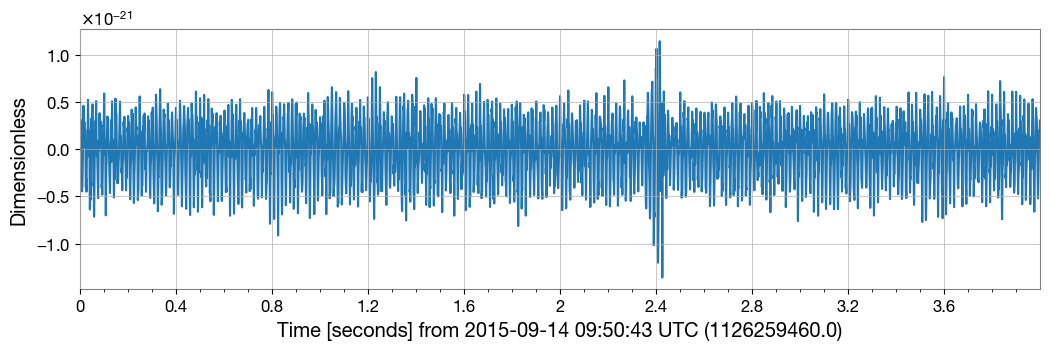

In [15]:
zoom = strain_filtered.crop(strain.t0.value + 13, strain.t0.value + 17)
zoom.plot()
plt.show()

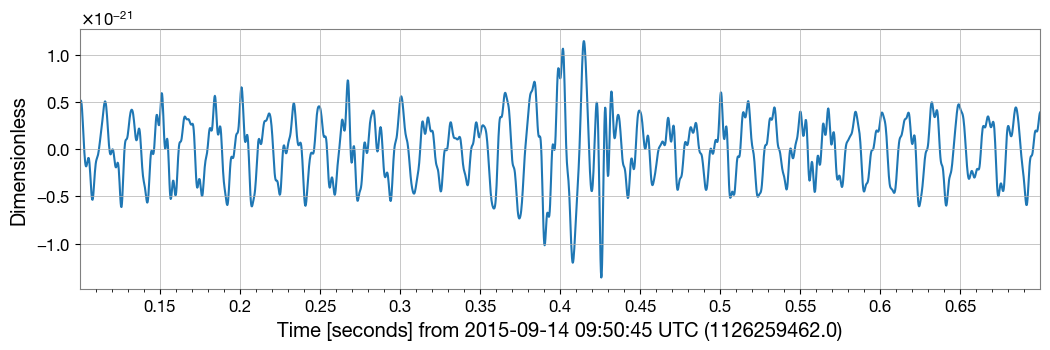

In [16]:
zoom2 = strain_filtered.crop(strain.t0.value + 15.1, strain.t0.value + 15.7)
zoom2.plot()
plt.show()

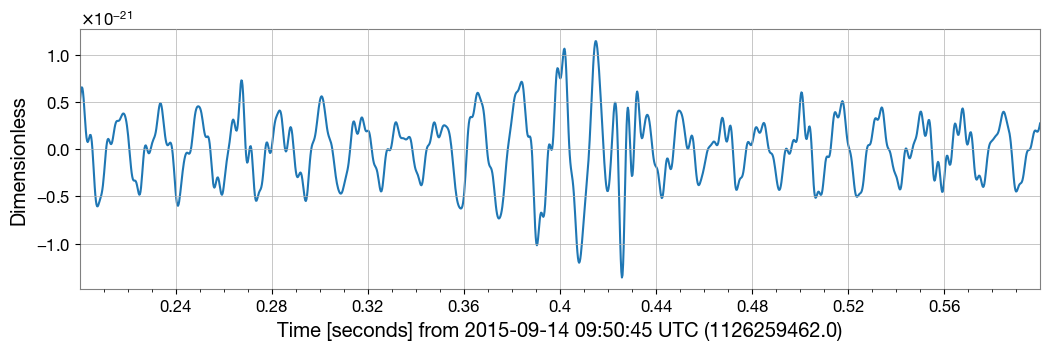

In [17]:
zoom3 = strain_filtered.crop(strain.t0.value + 15.2, strain.t0.value + 15.6)
zoom3.plot()
plt.show()